<a href="https://colab.research.google.com/github/cgm2179/Branch_2_Diffusion_Transformer_efficiency_for_small_model/blob/main/Section%208%20-%20Cameron's%20Version/regime%201/04_compare_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# regime 1 / Compare Results — all rules, equal wall-clock
Loads `results/{backprop,two_factor,three_factor,three_factor_v2}.json` from Drive and compares them (missing ones are skipped). Includes a dedicated three-factor **v1 vs v2** head-to-head.

## 1. Setup

In [1]:
import os, json, math, torch
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
device = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_DRIVE, DRIVE_SUBDIR = True, 'Section8_regime1'
if USE_DRIVE:
    try:
        from google.colab import drive; drive.mount('/content/drive')
        STORE = os.path.join('/content/drive/MyDrive', DRIVE_SUBDIR)
    except Exception as e:
        print('Drive mount failed:', e); STORE = os.path.join('/content', DRIVE_SUBDIR)
else:
    STORE = os.path.join('.', DRIVE_SUBDIR)
RESULTS_DIR = os.path.join(STORE, 'results'); CKPT_DIR = os.path.join(STORE, 'checkpoints')
METHODS = ['backprop', 'two_factor', 'three_factor', 'three_factor_v2', 'three_factor_v3']
LABELS  = {'backprop':'Backpropagation', 'two_factor':'Two-factor Hebbian',
           'three_factor':'Three-factor v1 (cos~0.5)', 'three_factor_v2':'Three-factor v2 (cos~0.09)',
           'three_factor_v3':'Three-factor v3 (cos~0.01)'}
COLORS  = {'backprop':'#1F3864', 'two_factor':'#B8860B', 'three_factor':'#C62828',
           'three_factor_v2':'#E67E22', 'three_factor_v3':'#7B1FA2'}
print('reading', RESULTS_DIR)

Mounted at /content/drive
reading /content/drive/MyDrive/Section8_regime1/results


## 2. Load Results

In [2]:
R = {}
for m in METHODS:
    p = os.path.join(RESULTS_DIR, f'{m}.json')
    if os.path.exists(p):
        R[m] = json.load(open(p))
        md, s = R[m]['meta'], R[m]['summary']
        print(f'loaded {m:14} {md["total_steps"]:>8,} steps  {md["wall_clock_sec"]/3600:5.2f}h  '
              f'final acc {s["final_acc"]:.3f}  best loss {s["best_loss"]:.4f}')
    else:
        print(f'MISSING {p}  (run the {m} notebook first)')

loaded backprop        692,954 steps   2.00h  final acc 0.986  best loss 0.0679
loaded two_factor      874,811 steps   2.00h  final acc 0.098  best loss 2.4146
loaded three_factor         33 steps   2.03h  final acc 0.493  best loss 1.4567
loaded three_factor_v2    1,367 steps   2.00h  final acc 0.880  best loss 0.3905
MISSING /content/drive/MyDrive/Section8_regime1/results/three_factor_v3.json  (run the three_factor_v3 notebook first)


## 3. Configuration

In [3]:
for m in R:
    md = R[m]['meta']
    print('='*64); print(LABELS[m])
    print(f'  P={md["P"]:,}  seed={md["seed"]}  device={md["device"]}  epochs={md["epochs"]:.3f}')
    print('  config:', json.dumps(md['config']))

Backpropagation
  P=1,013,066  seed=0  device=cuda  epochs=739.151
  config: {"METHOD": "backprop", "SEED": 0, "PATCH": 7, "EMBED_DIM": 176, "DEPTH": 4, "HEADS": 8, "MLP_RATIO": 2, "BATCH": 64, "TIME_BUDGET_HOURS": 2.0, "LR_BP": 0.0003}
Two-factor Hebbian
  P=1,013,066  seed=0  device=cuda  epochs=933.132
  config: {"METHOD": "two_factor", "SEED": 0, "PATCH": 7, "EMBED_DIM": 176, "DEPTH": 4, "HEADS": 8, "MLP_RATIO": 2, "BATCH": 64, "TIME_BUDGET_HOURS": 2.0, "ETA_HEBB": 0.001, "OJA_DECAY": 1.0}
Three-factor v1 (cos~0.5)
  P=1,013,066  seed=0  device=cuda  epochs=0.035
  config: {"METHOD": "three_factor", "SEED": 0, "PATCH": 7, "EMBED_DIM": 176, "DEPTH": 4, "HEADS": 8, "MLP_RATIO": 2, "BATCH": 64, "TIME_BUDGET_HOURS": 2.0, "SIGMA": 0.01, "M_PROBES": "mstar", "CHUNK_PROBES": 512, "LR_LOCAL": 0.05, "MOMENTUM": 0.9, "CLIP_GRAD_NORM": 1.0, "M": 337689}
Three-factor v2 (cos~0.09)
  P=1,013,066  seed=0  device=cuda  epochs=1.458
  config: {"METHOD": "three_factor_v2", "SEED": 0, "PATCH": 7, "E

## 4. Compare Loss Curves (all methods)

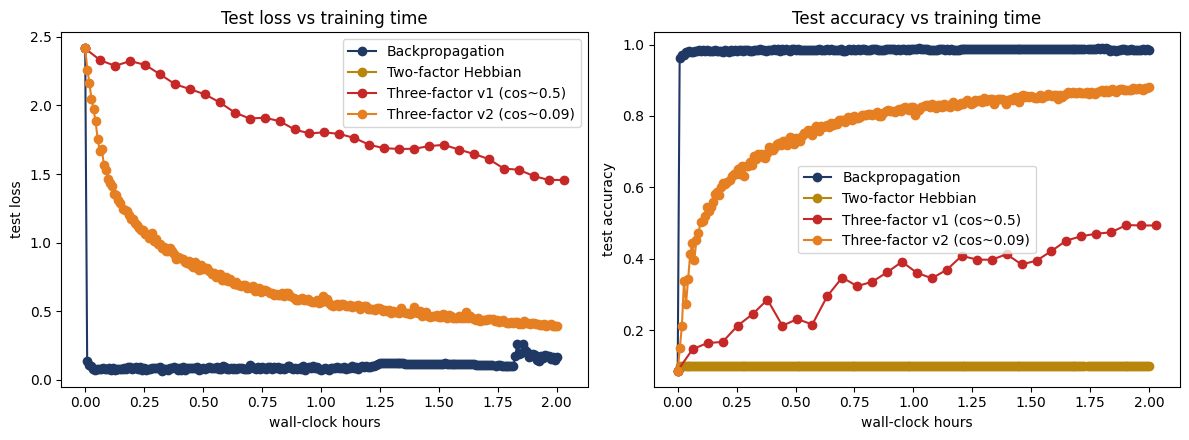

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for m in R:
    c = R[m]['curve']; hrs = [t/3600 for t in c['t_sec']]
    ax[0].plot(hrs, c['test_loss'], 'o-', color=COLORS[m], label=LABELS[m])
    ax[1].plot(hrs, c['test_acc'],  'o-', color=COLORS[m], label=LABELS[m])
ax[0].set_xlabel('wall-clock hours'); ax[0].set_ylabel('test loss'); ax[0].set_title('Test loss vs training time'); ax[0].legend()
ax[1].set_xlabel('wall-clock hours'); ax[1].set_ylabel('test accuracy'); ax[1].set_title('Test accuracy vs training time'); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Compare Predictions

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.54MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


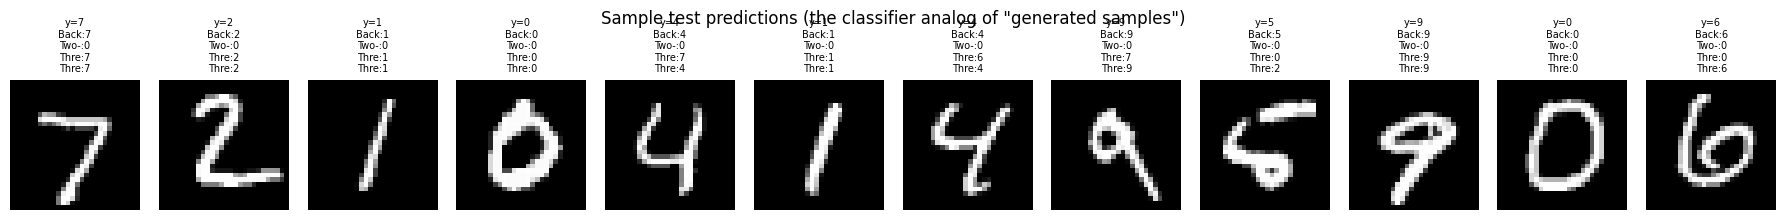

In [5]:
import math, torch
import torch.nn as nn
import torch.nn.functional as F

class MHSA(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        assert dim % heads == 0, "EMBED_DIM must be divisible by HEADS"
        self.h, self.dh = heads, dim // heads
        self.scale = self.dh ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        att = (q @ k.transpose(-2, -1)) * self.scale
        att = att.softmax(dim=-1)
        o = (att @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj(o)

class Block(nn.Module):
    def __init__(self, dim, heads, mlp_ratio):
        super().__init__()
        self.n1 = nn.LayerNorm(dim); self.attn = MHSA(dim, heads)
        self.n2 = nn.LayerNorm(dim)
        h = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, h), nn.GELU(), nn.Linear(h, dim))
    def forward(self, x):
        x = x + self.attn(self.n1(x))
        x = x + self.mlp(self.n2(x))
        return x

class ViT(nn.Module):
    def __init__(self, img=28, patch=7, in_ch=1, dim=176, depth=4, heads=8,
                 mlp_ratio=2, num_classes=10):
        super().__init__()
        assert img % patch == 0
        self.n = (img // patch) ** 2
        self.patch = nn.Conv2d(in_ch, dim, kernel_size=patch, stride=patch)
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(torch.zeros(1, self.n + 1, dim))
        nn.init.trunc_normal_(self.pos, std=0.02)
        nn.init.trunc_normal_(self.cls, std=0.02)
        self.blocks = nn.ModuleList([Block(dim, heads, mlp_ratio) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)
    def forward(self, x):
        B = x.shape[0]
        x = self.patch(x).flatten(2).transpose(1, 2)      # (B, n, dim)
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)[:, 0]
        return self.head(x)

import torchvision
_t = torchvision.datasets.MNIST('./data', train=False, download=True)
Xte = ((_t.data.float()/255-0.1307)/0.3081).unsqueeze(1).to(device); Yte = _t.targets.to(device)

def load_model(m):
    cfg = R[m]['meta']['config']
    net = ViT(28, cfg['PATCH'], 1, cfg['EMBED_DIM'], cfg['DEPTH'], cfg['HEADS'], cfg['MLP_RATIO'], 10).to(device)
    ck = torch.load(os.path.join(CKPT_DIR, f'{m}.pt'), map_location=device)['method']
    net.load_state_dict(ck['net'] if 'net' in ck else ck['params'])
    net.eval(); return net

N = 12; idx = torch.arange(N)
preds = {}
for m in R:
    with torch.no_grad(): preds[m] = load_model(m)(Xte[idx]).argmax(-1).cpu()
fig, axes = plt.subplots(1, N, figsize=(1.5*N, 2.2))
for j in range(N):
    axes[j].imshow(Xte[idx[j],0].cpu(), cmap='gray'); axes[j].axis('off')
    axes[j].set_title('y=%d\n' % Yte[idx[j]].item() +
                      '\n'.join('%s:%d' % (LABELS[m][:4], preds[m][j].item()) for m in R), fontsize=7)
plt.suptitle('Sample test predictions (the classifier analog of "generated samples")'); plt.tight_layout(); plt.show()

## 6. Compare Cost & Memory

In [6]:
def fwd_equiv(m):
    st = R[m]['meta']['total_steps']
    if m == 'three_factor': return st * 2 * R[m]['meta']['config'].get('M', 0)   # antithetic probes
    if m == 'backprop':     return st * 3                                        # fwd + ~2x bwd
    return st * 2                                                                # two-factor: acts + measured loss
print(f'{"method":26}{"steps":>10}{"fwd-pass-equiv":>16}{"wall h":>9}{"peak MB":>10}')
print('-'*71)
for m in R:
    md = R[m]['meta']
    print(f'{LABELS[m]:26}{md["total_steps"]:>10,}{fwd_equiv(m):>16,}{md["wall_clock_sec"]/3600:>9.2f}'
          f'{md.get("peak_mem_mb", float("nan")):>10.1f}')

method                         steps  fwd-pass-equiv   wall h   peak MB
-----------------------------------------------------------------------
Backpropagation              692,954       2,078,862     2.00     465.3
Two-factor Hebbian           874,811       1,749,622     2.00    1540.1
Three-factor v1 (cos~0.5)         33      22,287,474     2.03   16969.8
Three-factor v2 (cos~0.09)     1,367           2,734     2.00   16179.6


## 7. Head-to-head — three-factor v1 vs v2

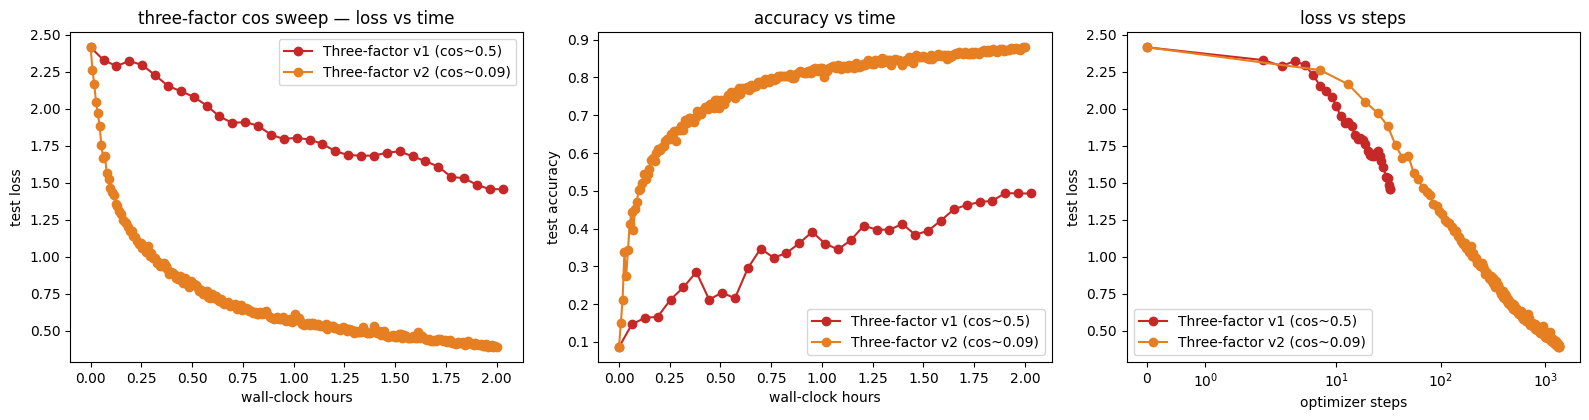

variant                                M    cos~     steps   best_loss  final_acc
---------------------------------------------------------------------------------
Three-factor v1 (cos~0.5)        337,689   0.500        33      1.4567      0.493
Three-factor v2 (cos~0.09)         8,192   0.090     1,367      0.3905      0.880

Lowest best test loss in the same wall-clock budget: Three-factor v2 (cos~0.09) (0.3905). Reading down the cos column shows whether pushing cos lower (fewer probes, more steps) keeps helping or finally breaks down.


In [7]:
# Head-to-head across the three-factor cos sweep: does MORE-but-noisier keep winning in equal wall-clock?
tf = [m for m in ['three_factor', 'three_factor_v2', 'three_factor_v3'] if m in R]
if len(tf) >= 2:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
    for m in tf:
        c = R[m]['curve']; hrs = [t/3600 for t in c['t_sec']]
        ax[0].plot(hrs, c['test_loss'], 'o-', color=COLORS[m], label=LABELS[m])
        ax[1].plot(hrs, c['test_acc'],  'o-', color=COLORS[m], label=LABELS[m])
        ax[2].plot(c['step'], c['test_loss'], 'o-', color=COLORS[m], label=LABELS[m])
    ax[0].set_xlabel('wall-clock hours'); ax[0].set_ylabel('test loss'); ax[0].set_title('three-factor cos sweep — loss vs time'); ax[0].legend()
    ax[1].set_xlabel('wall-clock hours'); ax[1].set_ylabel('test accuracy'); ax[1].set_title('accuracy vs time'); ax[1].legend()
    ax[2].set_xlabel('optimizer steps'); ax[2].set_ylabel('test loss'); ax[2].set_title('loss vs steps'); ax[2].set_xscale('symlog'); ax[2].legend()
    plt.tight_layout(); plt.show()

    print(f'{"variant":30}{"M":>10}{"cos~":>8}{"steps":>10}{"best_loss":>12}{"final_acc":>11}')
    print('-'*81)
    for m in tf:
        md, s = R[m]['meta'], R[m]['summary']
        M = md['config'].get('M') or 0; P = md['P']
        cos = (M/(M+P+1))**0.5 if M else float('nan')
        print(f'{LABELS[m]:30}{M:>10,}{cos:>8.3f}{md["total_steps"]:>10,}{s["best_loss"]:>12.4f}{s["final_acc"]:>11.3f}')
    best = min(tf, key=lambda m: R[m]['summary']['best_loss'])
    print(f'\nLowest best test loss in the same wall-clock budget: {LABELS[best]} '
          f'({R[best]["summary"]["best_loss"]:.4f}). Reading down the cos column shows whether pushing cos '
          f'lower (fewer probes, more steps) keeps helping or finally breaks down.')
else:
    print('Head-to-head needs >=2 three-factor variants present (run at least two of 03 / 05 / 06).')

## 8. Summary table (all methods)

In [8]:
print(f'{"Experiment":26}{"Epochs":>9}{"First loss":>12}{"Final loss":>12}{"Best loss":>11}{"Reduc %":>9}{"Test acc":>10}')
print('-'*89)
for m in R:
    md, s = R[m]['meta'], R[m]['summary']
    print(f'{LABELS[m]:26}{md["epochs"]:>9.3f}{s["initial_loss"]:>12.4f}{s["final_loss"]:>12.4f}'
          f'{s["best_loss"]:>11.4f}{s["reduction_pct"]:>9.1f}{s["final_acc"]:>10.3f}')
print('\n("Epochs" is fractional: in equal wall-clock, backprop runs many epochs while the three-factor '
      'rule runs a fraction of one -- that gap is the from-scratch barrier.)')

Experiment                   Epochs  First loss  Final loss  Best loss  Reduc %  Test acc
-----------------------------------------------------------------------------------------
Backpropagation             739.151      2.4146      0.1657     0.0679     97.2     0.986
Two-factor Hebbian          933.132      2.4146         nan     2.4146      0.0     0.098
Three-factor v1 (cos~0.5)     0.035      2.4146      1.4567     1.4567     39.7     0.493
Three-factor v2 (cos~0.09)    1.458      2.4146      0.3905     0.3905     83.8     0.880

("Epochs" is fractional: in equal wall-clock, backprop runs many epochs while the three-factor rule runs a fraction of one -- that gap is the from-scratch barrier.)
